Best gamma: 0.9930, Fitness: 6.7748


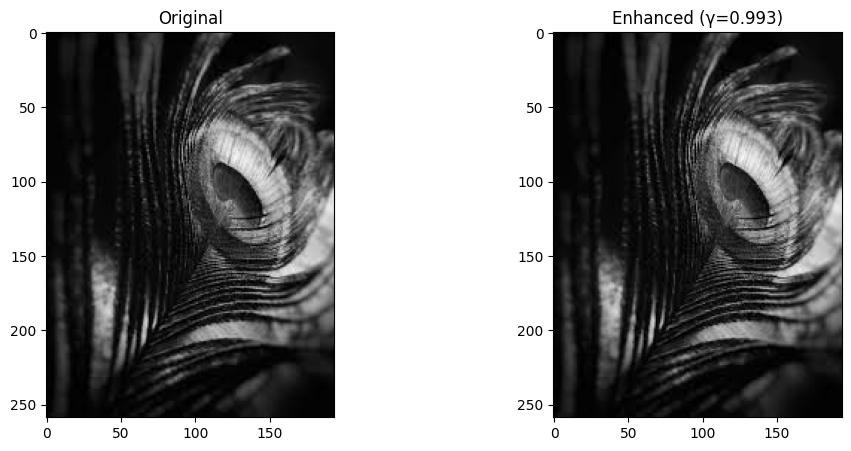

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Load grayscale image
# -------------------------------
img = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)
img = cv2.normalize(img, None, 0, 1, cv2.NORM_MINMAX, dtype=cv2.CV_32F)

# -------------------------------
# Step 2: Fitness function
# -------------------------------
def fitness_function(gamma):
    gamma = np.clip(gamma, 0.1, 5.0)
    enhanced = np.power(img, gamma)
    hist = np.histogram(enhanced, bins=256, range=(0, 1))[0]
    hist = hist / np.sum(hist)
    entropy = -np.sum(hist * np.log2(hist + 1e-12))
    return entropy  # Maximize entropy

# -------------------------------
# Step 3: Grey Wolf Optimizer (GWO)
# -------------------------------
def GWO(obj_func, wolves=10, max_iter=20, dim=1, lb=0.1, ub=5.0):
    # Initialize positions
    positions = np.random.uniform(lb, ub, (wolves, dim))

    # Initialize alpha, beta, delta wolves
    alpha_pos, beta_pos, delta_pos = np.zeros(dim), np.zeros(dim), np.zeros(dim)
    alpha_score, beta_score, delta_score = -np.inf, -np.inf, -np.inf

    for t in range(max_iter):
        for i in range(wolves):
            fitness = obj_func(positions[i])

            # Update alpha, beta, delta
            if fitness > alpha_score:
                delta_score, delta_pos = beta_score, beta_pos.copy()
                beta_score, beta_pos = alpha_score, alpha_pos.copy()
                alpha_score, alpha_pos = fitness, positions[i].copy()
            elif fitness > beta_score:
                delta_score, delta_pos = beta_score, beta_pos.copy()
                beta_score, beta_pos = fitness, positions[i].copy()
            elif fitness > delta_score:
                delta_score, delta_pos = fitness, positions[i].copy()

        # Update position of each wolf
        a = 2 - t * (2 / max_iter)
        for i in range(wolves):
            for j in range(dim):
                r1, r2 = np.random.rand(), np.random.rand()
                A1 = 2 * a * r1 - a
                C1 = 2 * r2
                D_alpha = abs(C1 * alpha_pos[j] - positions[i][j])
                X1 = alpha_pos[j] - A1 * D_alpha

                r1, r2 = np.random.rand(), np.random.rand()
                A2 = 2 * a * r1 - a
                C2 = 2 * r2
                D_beta = abs(C2 * beta_pos[j] - positions[i][j])
                X2 = beta_pos[j] - A2 * D_beta

                r1, r2 = np.random.rand(), np.random.rand()
                A3 = 2 * a * r1 - a
                C3 = 2 * r2
                D_delta = abs(C3 * delta_pos[j] - positions[i][j])
                X3 = delta_pos[j] - A3 * D_delta

                positions[i][j] = np.clip((X1 + X2 + X3) / 3, lb, ub)

    return alpha_pos, alpha_score

# -------------------------------
# Step 4: Run GWO
# -------------------------------
best_gamma, best_score = GWO(fitness_function, wolves=10, max_iter=25)
print(f"Best gamma: {best_gamma[0]:.4f}, Fitness: {best_score:.4f}")

# -------------------------------
# Step 5: Enhance image
# -------------------------------
enhanced_img = np.power(img, best_gamma[0])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(enhanced_img, cmap='gray')
plt.title(f"Enhanced (γ={best_gamma[0]:.3f})")

plt.show()
